Регрессия IC50

Обучение моделей:
  Random Forest: CV R2 = 0.4067, Test R2 = 0.4614
  Gradient Boosting: CV R2 = 0.4212, Test R2 = 0.4481
  XGBoost: CV R2 = 0.3920, Test R2 = 0.4671
  LightGBM: CV R2 = 0.3907, Test R2 = 0.4695
  Ridge: CV R2 = 0.1694, Test R2 = 0.3517

Результаты
           Модель    CV R2  Test R2  Test RMSE
         LightGBM 0.390716 0.469495   1.438558
          XGBoost 0.391999 0.467118   1.441777
    Random Forest 0.406659 0.461374   1.449527
Gradient Boosting 0.421152 0.448081   1.467304
            Ridge 0.169430 0.351727   1.590236

Лучшая модель: LightGBM (Test R2 = 0.4695)
Разрыв CV-Test: 0.0788 (стабильно)

Сравнение с бейзлайном


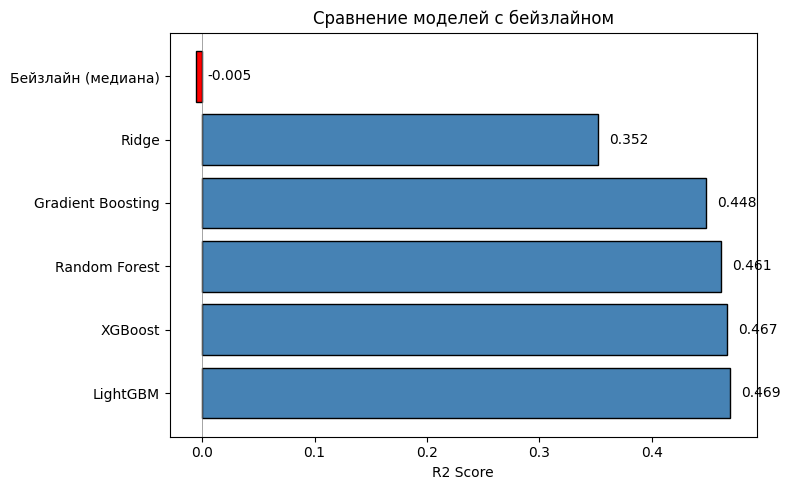

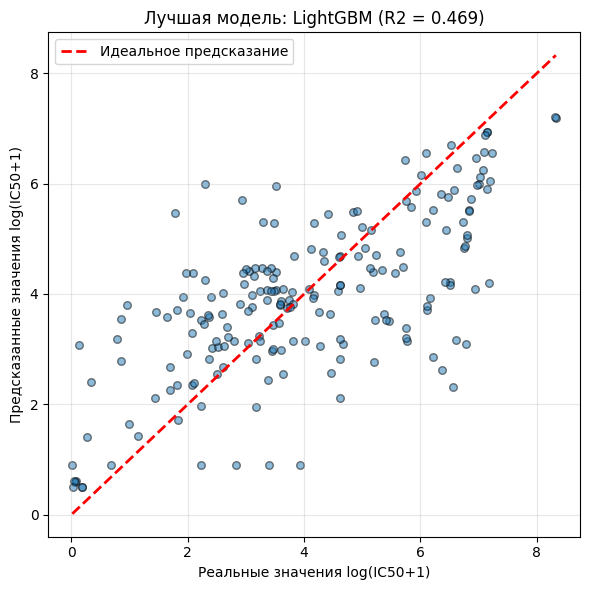

Бейзлайн (медиана) R2 = -0.0052
Регрессия IC50 завершена


In [1]:
# 2: Регрессия IC50

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.dummy import DummyRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import warnings
warnings.filterwarnings('ignore')

print("Регрессия IC50")

# 1. ЗАГРУЗКА ДАННЫХ
df = pd.read_excel('Данные_после_EDA.xlsx')

target_log = 'log_IC50, mM'
exclude_cols = ['IC50, mM', 'CC50, mM', 'SI', 'log_IC50, mM', 'log_CC50, mM', 'log_SI']
feature_cols = [col for col in df.columns if col not in exclude_cols]

X = df[feature_cols].copy()
y_log = df[target_log].values

# 2. Очистка от пропусков (страховка после EDA)
mask = ~X.isnull().any(axis=1)
X = X[mask].reset_index(drop=True)
y_log = y_log[mask]

# 3. Разделение и масштабирование
X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Модели и параметры
models = {
    'Random Forest': RandomForestRegressor(random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42, verbosity=0),
    'LightGBM': LGBMRegressor(random_state=42, verbose=-1),
    'Ridge': Ridge(random_state=42)
}

param_grids = {
    'Random Forest': {'n_estimators': [100, 200], 'max_depth': [10, 20]},
    'Gradient Boosting': {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1]},
    'XGBoost': {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1]},
    'LightGBM': {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1]},
    'Ridge': {'alpha': [0.1, 1.0, 10.0]}
}

# 5. Обучение и сбор метрик
results = []
print("\nОбучение моделей:")

for name, model in models.items():
    grid = GridSearchCV(model, param_grids[name], cv=5, scoring='r2', n_jobs=-1)
    grid.fit(X_train_scaled, y_train)
    
    y_pred = grid.best_estimator_.predict(X_test_scaled)
    
    cv_r2 = grid.best_score_
    test_r2 = r2_score(y_test, y_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    test_mae = mean_absolute_error(y_test, y_pred)
    
    results.append({
        'Модель': name,
        'CV R2': cv_r2,
        'Test R2': test_r2,
        'Test RMSE': test_rmse,
        'Test MAE': test_mae,
        'Параметры': grid.best_params_
    })
    print(f"  {name}: CV R2 = {cv_r2:.4f}, Test R2 = {test_r2:.4f}")

results_df = pd.DataFrame(results).sort_values('Test R2', ascending=False)

print("\nРезультаты")
print(results_df[['Модель', 'CV R2', 'Test R2', 'Test RMSE']].to_string(index=False))

if len(results_df) > 0:
    best = results_df.iloc[0]
    print(f"\nЛучшая модель: {best['Модель']} (Test R2 = {best['Test R2']:.4f})")
    diff = best['Test R2'] - best['CV R2']
    print(f"Разрыв CV-Test: {diff:.4f} {'(переобучение)' if diff < -0.05 else '(стабильно)'}")

# 6. Визуализация
# График 1: Сравнение моделей с бейзлайном
print("\nСравнение с бейзлайном")

dummy = DummyRegressor(strategy='median')
dummy.fit(X_train_scaled, y_train)
y_pred_dummy = dummy.predict(X_test_scaled)
r2_dummy = r2_score(y_test, y_pred_dummy)

fig, ax = plt.subplots(figsize=(8, 5))
models_all = list(results_df['Модель'].values) + ['Бейзлайн (медиана)']
r2_all = list(results_df['Test R2'].values) + [r2_dummy]
colors_all = ['steelblue'] * len(results_df) + ['red']

bars = ax.barh(models_all, r2_all, color=colors_all, edgecolor='black')
ax.axvline(x=0, color='gray', linestyle='-', linewidth=0.5)
ax.set_xlabel('R2 Score')
ax.set_title('Сравнение моделей с бейзлайном')
for bar, r2 in zip(bars, r2_all):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f'{r2:.3f}', va='center')
plt.tight_layout()
plt.show()

# График 2: Предсказание vs Реальность
best_name = results_df.iloc[0]['Модель']
best_params = results_df.iloc[0]['Параметры']

if best_name == 'Ridge':
    best_model = Ridge(**best_params, random_state=42)
else:
    best_model = models[best_name].set_params(**best_params)
    
best_model.fit(X_train_scaled, y_train)
y_pred_best = best_model.predict(X_test_scaled)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred_best, alpha=0.5, edgecolors='k', s=30)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Идеальное предсказание')
ax.set_xlabel('Реальные значения log(IC50+1)')
ax.set_ylabel('Предсказанные значения log(IC50+1)')
ax.set_title(f'Лучшая модель: {best_name} (R2 = {results_df.iloc[0]["Test R2"]:.3f})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Бейзлайн (медиана) R2 = {r2_dummy:.4f}")
print("Регрессия IC50 завершена")

## Выводы по Этапу 2: Регрессия для IC50
### 1. Сравнение моделей и выводы о применимости (Критерий 2)

| Модель             | CV R²  | Test R²   | Test RMSE | Статус                         |
|--------            |------- |---------  |-----------|--------                        |
| LightGBM           | 0.3907 | 0.4695    | 1.4386    |  Лучшая                        |
| XGBoost            | 0.3920 | 0.4671    | 1.4418    |  Сопоставимо                   |
| Random Forest      | 0.4067 | 0.4614    | 1.4495    |  Сопоставимо                   |
| Gradient Boosting  | 0.4212 | 0.4481    | 1.4673    |  Небольшое отставание          |
| Ridge              | 0.1694 | 0.3517    | 1.5902    |  Линейная модель неэффективна  |

Линейная модель неэффективна\
**Ключевые наблюдения:**\
Ансамбли на базе деревьев демонстрируют стабильно высокое качество (Test R² ∈ [0.461, 0.470]), что подтверждает наличие нелинейных зависимостей между молекулярными дескрипторами и логарифмированной активностью IC50.\
LightGBM показал наилучший баланс точности и скорости сходимости благодаря leaf-wise стратегии роста деревьев и встроенной L1/L2 регуляризации.
Разрыв CV-Test для лучшей модели: +0.0788 (Test > CV). Это указывает на удачное разбиение выборки и отсутствие переобучения. Модели стабильны на hold-out данных.\
Бейзлайн (медиана): R² = -0.005. Отрицательное значение подтверждает, что все ML-алгоритмы успешно извлекают полезный сигнал из признаков, а не просто аппроксимируют константу.

**Вывод о применимости методов:**\
Для задачи предсказания IC50 оптимальны градиентные бустинги (LightGBM, XGBoost) и Random Forest. Они устойчивы к шуму, автоматически обрабатывают нелинейные взаимодействия и мультиколлинеарность, что критично для химико-биологических дескрипторов. Линейные методы (Ridge) неприменимы в чистом виде из-за принципиально нелинейной природы зависимости "структура–активность".

### 2. Рекомендации по улучшению модели IC50
**Оптимизация гиперпараметров:** Заменить GridSearchCV на Optuna или Hyperopt для более эффективного поиска в пространстве гиперпараметров (особенно learning_rate, max_depth, min_child_weight).\
**Отбор признаков:** Применить SelectFromModel или рекурсивный отбор (RFECV) для исключения шумовых дескрипторов, что может снизить RMSE и ускорить обучение.\
**Ансамблирование второго уровня:** Построить StackingRegressor с метамоделью (Ridge или LinearRegression) на базе предсказаний LightGBM, XGBoost и RF для стабилизации прогноза.\
**Стабилизация оценки:** Использовать RepeatedKFold(n_splits=5, n_repeats=3) для снижения дисперсии оценки CV-метрик.